In [1]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




/tmp/ipykernel_911203/2667599699.py:9: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# !pip install abacusutils


In [4]:
ldir_base = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos/'
zmin = 0.01
zmax = 2
# get the list all directories in the base directory
dirs = [d for d in os.listdir(ldir_base) if os.path.isdir(os.path.join(ldir_base, d)) and d.startswith('z')]
# extract the redshift from the directory name which is float without the 'z' prefix:
redshifts = np.array([float(d[1:]) for d in dirs if d.startswith('z')])
# sort the directories and redshifts
sorted_indices = np.argsort(redshifts)
dirs = [dirs[i] for i in sorted_indices]
redshifts = redshifts[sorted_indices]
indsel = np.where((redshifts >= zmin) & (redshifts <= zmax))[0]
redshifts = redshifts[indsel]
dirs = [dirs[i] for i in indsel]

print(dirs)


['z0.019', 'z0.039', 'z0.059', 'z0.080', 'z0.102', 'z0.124', 'z0.147', 'z0.171', 'z0.196', 'z0.222', 'z0.248', 'z0.276', 'z0.304', 'z0.334', 'z0.365', 'z0.397', 'z0.431', 'z0.466', 'z0.503', 'z0.542', 'z0.582', 'z0.625', 'z0.671', 'z0.718', 'z0.769', 'z0.823', 'z0.881', 'z0.943', 'z1.009', 'z1.081', 'z1.158', 'z1.242', 'z1.334', 'z1.435', 'z1.546', 'z1.670', 'z1.810', 'z1.968']


In [ ]:
import h5py as h5
import healpy as hp

fname = '/mnt/ceph/users/abayer/fastpm/halfdome/stampede2_3750Mpch_6144cube/final_res/halos/lightcone_100.hdf5'
with h5.File(fname, 'r') as f:
    # print(f.keys())
    M200c = f['halo_mass_m200c'][:]
    redshift = f['redshift'][:]
    pos = f['Position'][:]
    vel = f['Velocity'][:]

ra, dec = hp.vec2ang(pos, lonlat=True)




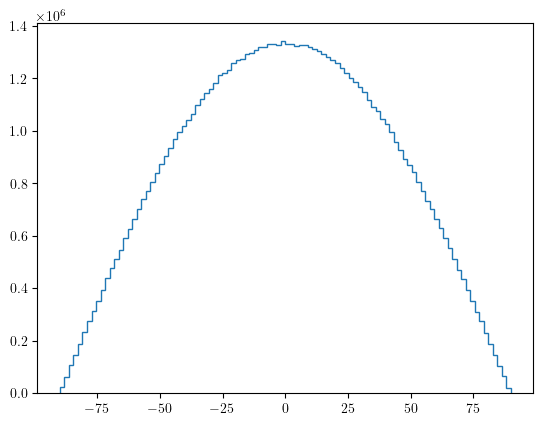

In [14]:
pl.figure()
_ = pl.hist(dec, bins=100, histtype='step', label='RA')
# pl.yscale('log')



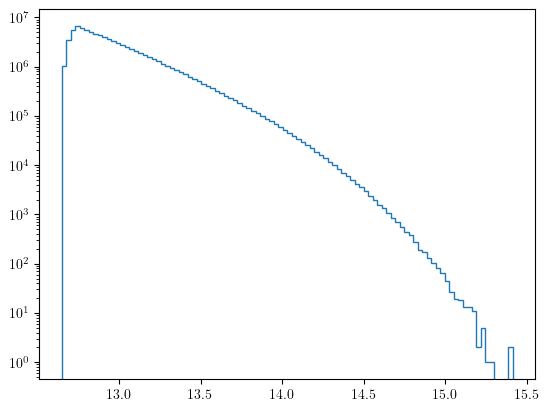

In [5]:
pl.figure()
_ = pl.hist(np.log10(M200c), bins=100, histtype='step', label='M200c')
pl.yscale('log')



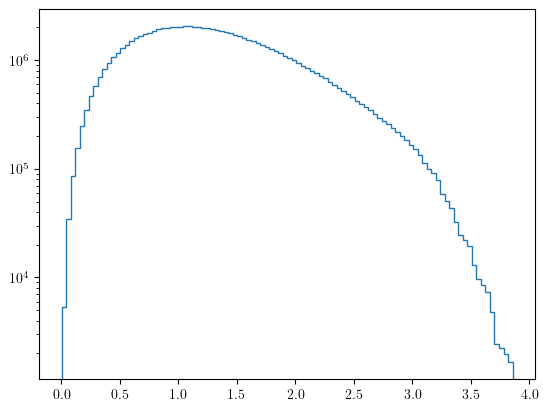

In [7]:
pl.figure()
_ = pl.hist(redshift, bins=100, histtype='step', label='M200c')
pl.yscale('log')



In [3]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
import gc
# Palatino
# pl.rc('font', family='DejaVu Sans')
import ast
import yaml

# nside = int(ast.literal_eval(sys.argv[1]))
# print('nside: ', nside)
# jdevice = int(ast.literal_eval(sys.argv[2]))
# print('jdevice: ', jdevice)
# Ndevices = int(ast.literal_eval(sys.argv[3]))
# print('Ndevices: ', Ndevices)
nside = 2048
jdevice = 7
# jdevice = 0
Ndevices = 8

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

halo_params_dict['rmin'] = 0.0001
halo_params_dict['rmax'] = 10.0
halo_params_dict['nr'] = 126
halo_params_dict['zmin'] = 0.01
halo_params_dict['zmax'] = 4.1
halo_params_dict['nz'] = 127
halo_params_dict['lg10_Mmin'] = 12.0
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 128

from godmax.get_B12_profile import Battaglia_12_16
import helpers.constants as constants
# cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8':0.8159 ,'ns': 0.9667}
# B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)


B12_test = Battaglia_12_16(sim_params_dict={'cosmo':cosmo_params_dict, 'init_power':True}, halo_params_dict=halo_params_dict)



1 1


In [ ]:
from astropy.io import fits
import h5py as h5
import healpy as hp

fname = '/mnt/ceph/users/abayer/fastpm/halfdome/stampede2_3750Mpch_6144cube/final_res/halos/lightcone_100.hdf5'
with h5.File(fname, 'r') as f:
    # print(f.keys())
    M200c_all = f['halo_mass_m200c'][:]
    z_all = f['redshift'][:]
    pos = f['Position'][:]
    v_all = f['Velocity'][:]

ra_all, dec_all = hp.vec2ang(pos, lonlat=True)

# get the line of sight velocity:
vlos_all = np.sum(v_all * hp.ang2vec(ra_all, dec_all, lonlat=True), axis=1)


indsel = np.where((z_all>0.001) & (M200c_all<4e16) & (M200c_all>(10**12.5)))[0]
ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
# M200m_all = M200m_all[indsel]
vlos_all = vlos_all[indsel]
print('total number of halos: ', len(M200c_all))

argsort = np.flip(np.argsort(M200c_all))
Nsel = (len(argsort)//Ndevices)*Ndevices
argsort = argsort[:Nsel]
Ngal_per_device = Nsel//Ndevices
argsort_here = argsort[jdevice*Ngal_per_device:(jdevice+1)*Ngal_per_device]
ra_all = ra_all[argsort_here]
dec_all = dec_all[argsort_here]
z_all = z_all[argsort_here]
M200c_all = M200c_all[argsort_here]
vlos_all = vlos_all[argsort_here]

print('number of halos: ', len(M200c_all), ', mean log(M200c)', np.mean(np.log10(M200c_all)), ', mean z', np.mean(z_all))
print('log10Mmin: ', np.min(np.log10(M200c_all)), ', log10Mmax: ', np.max(np.log10(M200c_all)))
print('zmin: ', np.min(z_all), ', zmax: ', np.max(z_all))
print('ra min: ', np.min(ra_all), ', ra max: ', np.max(ra_all))
print('dec min: ', np.min(dec_all), ', dec max: ', np.max(dec_all))




total number of halos:  85214373
number of halos:  10651796 , mean log(M200c) 12.706386891352324 , mean z 1.7949702
log10Mmin:  12.649221403047383 , log10Mmax:  12.7343286467122
zmin:  0.05000186 , zmax:  3.2770214
ra min:  2.5357343e-05 , ra max:  360.0
dec min:  -89.944046 , dec max:  90.0


In [5]:
10651796//5e5
# Ngal_per_device



21.0

In [6]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
import jax_cosmo.background as bkgrd
from godmax.get_sim_maps import get_sim_map
import h5py as h5


jax.clear_caches()
# nside = 4096
# nside = 8192
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_halfdome/'
# save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
# save_map_fname = sdir + f'kSZ_sim_B16_testv11_nside_{nside}_split_{jdevice}_{Ndevices}.pkl'
save_map_fname = sdir + f'tSZ_sim_B12_testv11_nside_{nside}_split_{jdevice}_{Ndevices}.pkl'
# if not os.path.exists(save_kszmap_fname):
halo_ra, halo_dec = ra_all, dec_all
halo_z = z_all
halo_m = M200c_all

print('number of halos: ', len(halo_m))
M_all = halo_m
ra_all = halo_ra
dec_all = halo_dec
z_all = halo_z
# vlos_all = np.zeros_like(z_all)
nsel = len(M_all)

# nh_max = 4e4
# nh_max = 4e3
if nside == 8192:
    nh_max = 4e3
elif nside == 4096:
    nh_max = 5e4
elif nside == 2048:
    nh_max = 5e5
elif nside == 1024:
    nh_max = 2e5
else:
    print('nside not supported')
# nh_max = 1e5
# nh_max = 2e6
if nsel > nh_max:
    num_chunks = int(np.ceil(nsel / nh_max))
else:
    num_chunks = 1



map_test = np.zeros(12*nside**2, dtype=np.float32)
from tqdm import tqdm
# for i in tqdm(range(num_chunks)):
for i in tqdm(range(1)):    
    from multiprocessing import Pool, cpu_count
    if i == num_chunks - 1:
        M_all_chunk = M_all[int(i*nh_max):]
        ra_all_chunk = ra_all[int(i*nh_max):]
        dec_all_chunk = dec_all[int(i*nh_max):]
        z_all_chunk = z_all[int(i*nh_max):]
        vlos_all_chunk = vlos_all[int(i*nh_max):]
    else:
        M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
        ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
        dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
        z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
        vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

    mock_params_dict = {}
    mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
    mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
    mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
    mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
    mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
    mock_params_dict['nside'] = nside
    mock_params_dict['get_ymap'] = True
    # mock_params_dict['get_taumap'] = True
    # mock_params_dict['get_kSZmap'] = True

    mock_params_dict['smooth_profiles'] = True

    halo_cat_scale_fac = 1./(1. + z_all_chunk)

    halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax,halo_cat_scale_fac) * 1e9
    mdef_delta=200
    halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


    halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
    halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax,halo_cat_scale_fac)
    max_paint_R200c_factor = 3.


    ra_all_np = np.array(ra_all_chunk)
    dec_all_np = np.array(dec_all_chunk)

    ra_all_np = np.clip(np.array(ra_all_chunk), 0.01, 359.99)
    dec_all_np = np.clip(np.array(dec_all_chunk), -89.99, 89.99)


    z_all_np = np.array(z_all_chunk)
    halo_cat_R200c_np = np.array(halo_cat_R200c)
    halo_cat_DV_np = np.array(halo_cat_DA)
    halo_vlos_np = np.array(vlos_all_chunk)
    def process_halo(jhalo):
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

        nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

        def hav(theta):
            return np.sin(theta / 2.) ** 2.

        ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
        ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
        theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

        physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

        nearby_pix_array = np.array(nearby_pix)
        distances_pix_array = np.array(physical_distances_jhalo)
        logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
        z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
        v_los_ind_array = np.ones(len(nearby_pix)) * vlos_all_chunk[jhalo]
        ang_distance_jhalo = np.ones(len(nearby_pix)) * halo_cat_DV_np[jhalo]
        rp_max_jhalo = np.ones(len(nearby_pix)) * max_paint_R200c_factor * halo_cat_R200c_np[jhalo]
        return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix), ang_distance_jhalo, rp_max_jhalo)

    def concatenate_results(results):
        # Pre-compute lengths for each part
        lengths = np.array([len(result[0]) for result in results])
        total_length = lengths.sum()

        # Pre-allocate arrays
        nearby_pix_all = np.empty(total_length, dtype=int)
        distances_pix_all = np.empty(total_length)
        logM_ind_all = np.empty(total_length)
        z_ind_all = np.empty(total_length)
        vlos_ind_all = np.empty(total_length)
        ang_distance_all = np.empty(total_length)
        rp_max_all = np.empty(total_length)

        # Calculate start and end indices
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.roll(end_ind_all, 1)
        start_ind_all[0] = 0

        # Use array slicing for assignment
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            logM_ind_all[start:end] = result[2]
            z_ind_all[start:end] = result[3]
            vlos_ind_all[start:end] = result[4]
            ang_distance_all[start:end] = result[6]
            rp_max_all[start:end] = result[7]

        return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all


    # if __name__ == "__main__":
    with Pool(cpu_count()) as pool:
        results = pool.map(process_halo, range(len(z_all_chunk)))

    nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all = concatenate_results(results)

    mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
    mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
    mock_params_dict['ang_distance_all'] = jnp.array(ang_distance_all)[start_ind_all]
    mock_params_dict['rp_max_all'] = jnp.array(rp_max_all)[start_ind_all]
    mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
    mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))
    # mock_params_dict['norm_profiles'] = True

    mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=B12_test)

    # find non-finite values and set them to zero
    # ymap_test += jnp.nan_to_num(mock_map_test.ymap_final)
    map_test += np.array(np.nan_to_num(mock_map_test.ymap_final), dtype=np.float32)

    # del mock_map_test, mock_params_dict
    # del nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all
    # jax.clear_caches()
    # gc.collect()




number of halos:  10651796


100%|██████████| 1/1 [00:43<00:00, 43.65s/it]


In [7]:
nside = hp.npix2nside(len(map_test))
# nside = hp.npix2nside(len(map_final))
cls_yy = hp.anafast(map_test, lmax=2*nside)


In [ ]:
# import jax
# node_rank = jax.process_index()
# num_nodes = jax.process_count()
# n_gpus_local = jax.local_device_count()
# print(node_rank, num_nodes, n_gpus_local)




0 1 2


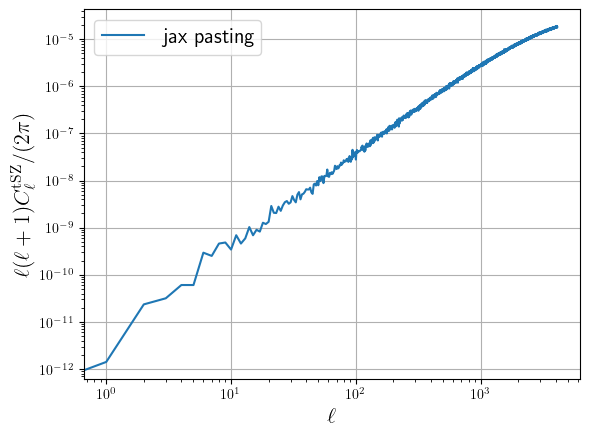

In [8]:
ell_array = np.arange(len(cls_yy))
fac = 1e12 * ell_array * (ell_array + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_array, fac * cls_yy, label='jax pasting', marker='')
# pl.plot(dfL[:,0], facL*dfL[:,1], ls='--', label='From Linda')
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell + 1)C_\ell^{\rm tSZ}/(2\pi)$', fontsize=16)
# pl.xlim(1, 2048)
pl.legend(fontsize=15)
pl.xscale('log')
pl.yscale('log')
pl.grid()
# pl.ylim(1e-5, 3)




In [41]:
# ra_all_np = np.clip(np.array(ra_all_chunk), 0.01, 359.99)
# dec_all_np = np.clip(np.array(dec_all_chunk), -89.99, 89.99)
# print(np.amin(ra_all_np), np.amax(ra_all_np))
# print(np.amin(dec_all_np), np.amax(dec_all_np))


In [42]:
# # np.amin(dec_all_np), np.amax(dec_all_np)

# jhalo = 446053
# print(ra_all_np[jhalo], dec_all_np[jhalo])
# print(hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True))

# # jhalo = 446053
# # hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)


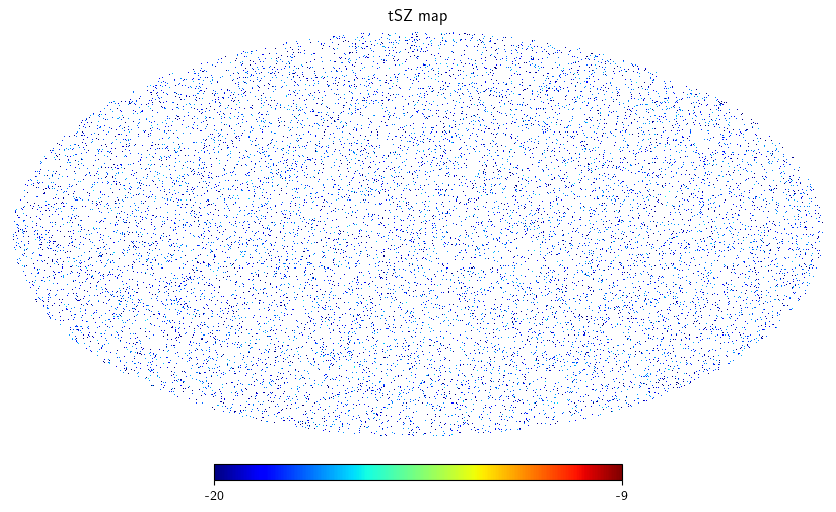

In [6]:
hp.mollview(np.log((map_test)), title='tSZ map', cmap='jet', min=-20, max=-9)





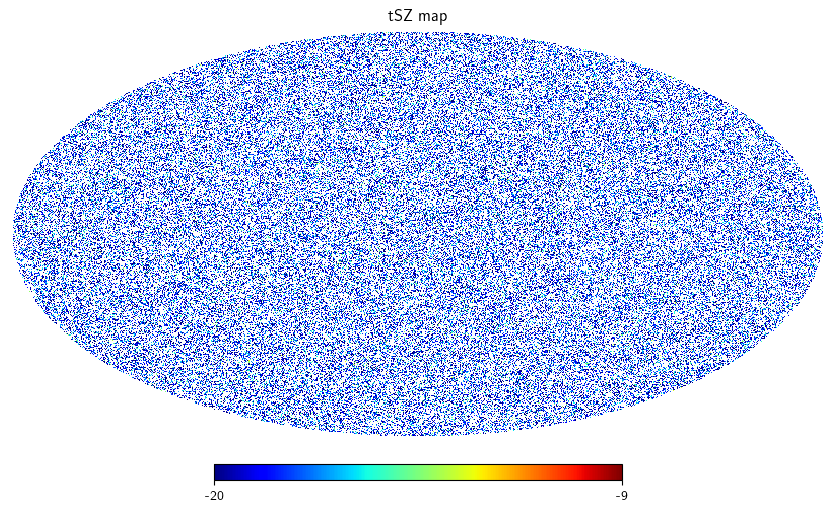

In [43]:
hp.mollview(np.log((map_test)), title='tSZ map', cmap='jet', min=-20, max=-9)




In [17]:
import healpy as hp
import pickle as pk
ldir = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_halfdome'
# ji = 0
# df = pk.load(open(f'{ldir}/tSZ_sim_B12_testv11_nside_2048_split_{ji}_8.pkl','rb'))
map_final = np.zeros(12*(2048**2))
for ji in range(4):
    df = pk.load(open(f'{ldir}/tSZ_sim_B12_testv11_nside_2048_split_{ji}_8_zmax_1.5.pkl','rb'))
    # print(df.keys())
    map_final += df['map_test']

# map_final = np.zeros(12*(2048**2))
# ji = 0
# df = pk.load(open(f'{ldir}/tSZ_sim_B12_testv11_nside_2048_split_{ji}_8_zmax_1.5.pkl','rb'))
# map_final += df['map_test']



In [18]:
# nside = hp.npix2nside(len(map_test))
nside = hp.npix2nside(len(map_final))
cls_yy = hp.anafast(map_final, lmax=2*nside)




In [19]:
dfL = np.loadtxt('/mnt/home/spandey/ceph/paste_godmax/GODMAX/notebooks/pasting/tSZ_Cls_seed_100.txt')
print(dfL.shape)
facL = 1e12 * dfL[:,0] * (dfL[:,0] + 1) / (2 * np.pi)



(4097, 2)


(1e-05, 3)

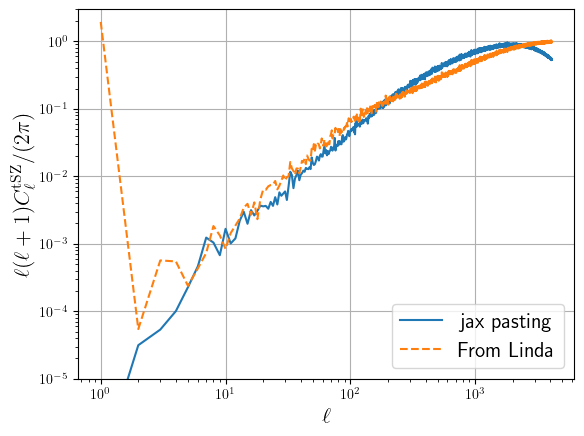

In [20]:
ell_array = np.arange(len(cls_yy))
fac = 1e12 * ell_array * (ell_array + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_array, fac * cls_yy, label='jax pasting', marker='')
pl.plot(dfL[:,0], facL*dfL[:,1], ls='--', label='From Linda')
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell + 1)C_\ell^{\rm tSZ}/(2\pi)$', fontsize=16)
# pl.xlim(1, 2048)
pl.legend(fontsize=15)
pl.xscale('log')
pl.yscale('log')
pl.grid()
pl.ylim(1e-5, 3)




(1e-05, 3)

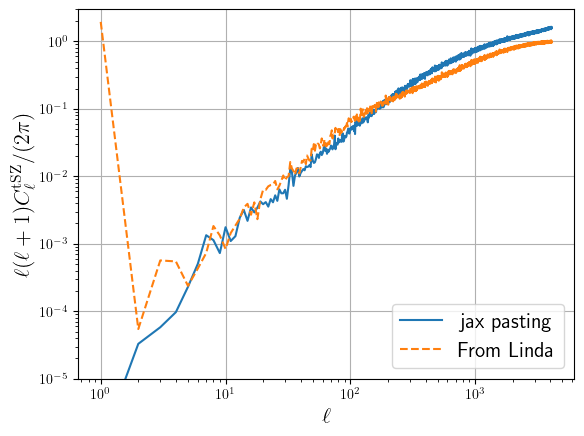

In [106]:
ell_array = np.arange(len(cls_yy))
fac = 1e12 * ell_array * (ell_array + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_array, fac * cls_yy, label='jax pasting', marker='')
pl.plot(dfL[:,0], facL*dfL[:,1], ls='--', label='From Linda')
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell + 1)C_\ell^{\rm tSZ}/(2\pi)$', fontsize=16)
# pl.xlim(1, 2048)
pl.legend(fontsize=15)
pl.xscale('log')
pl.yscale('log')
pl.grid()
pl.ylim(1e-5, 3)




(1e-05, 10)

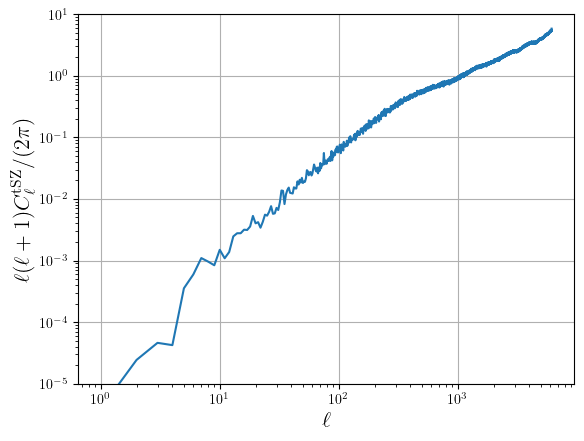

In [27]:
ell_array = np.arange(len(cls_yy))
fac = 1e12 * ell_array * (ell_array + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_array, fac * cls_yy, label='tSZ map', marker='')
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell + 1)C_\ell^{\rm tSZ}/(2\pi)$', fontsize=16)
# pl.xlim(1, 2048)
pl.xscale('log')
pl.yscale('log')
pl.grid()
pl.ylim(1e-5, 10)




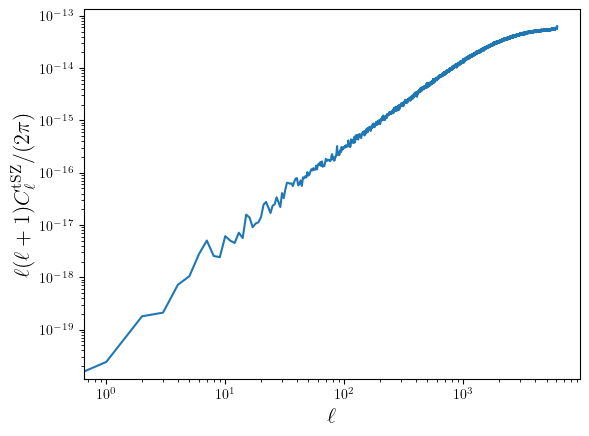

In [ ]:
ell_array = np.arange(len(cls_yy))
fac = 1e12* ell_array * (ell_array + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_array, fac * cls_yy, label='tSZ map', marker='')
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell + 1)C_\ell^{\rm tSZ}/(2\pi)$', fontsize=16)
# pl.xlim(1, 2048)
pl.xscale('log')
pl.yscale('log')
pl.grid()
pl.ylim(1e-5, 10)

